# 1.4.4 Smoothing Images

## Kernel Convolution

In [148]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [149]:
l=1
kernel = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],np.float32)

In [150]:
kernel

array([[ 0., -1.,  0.],
       [-1.,  4., -1.],
       [ 0., -1.,  0.]], dtype=float32)

In [151]:
img = np.random.randint(10, size=(12,12))
#img = np.ones((10,10),np.float32)

In [152]:
img

array([[0, 5, 9, 9, 1, 9, 3, 2, 1, 8, 5, 3],
       [9, 3, 2, 1, 8, 2, 4, 3, 1, 6, 5, 7],
       [3, 6, 1, 1, 0, 0, 8, 5, 5, 1, 2, 4],
       [6, 2, 6, 7, 8, 1, 6, 3, 5, 5, 6, 3],
       [5, 7, 7, 6, 2, 5, 6, 0, 1, 7, 0, 3],
       [3, 4, 1, 0, 8, 6, 0, 3, 2, 7, 6, 8],
       [0, 1, 1, 6, 5, 9, 7, 8, 0, 5, 3, 2],
       [7, 5, 8, 7, 2, 1, 0, 9, 7, 0, 0, 1],
       [0, 4, 2, 2, 7, 4, 3, 7, 6, 7, 7, 3],
       [5, 0, 2, 4, 6, 8, 7, 9, 1, 1, 3, 8],
       [9, 7, 5, 9, 3, 5, 4, 9, 6, 7, 5, 5],
       [1, 7, 5, 1, 9, 6, 2, 6, 9, 2, 4, 8]])

In [153]:
h,w=img.shape

In [154]:
print(h,w)

12 12


In [155]:
#[*range(-2,3)]

In [156]:
dst = np.zeros((h,w),dtype = int)

In [157]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i,j]=t        

In [158]:
img

array([[0, 5, 9, 9, 1, 9, 3, 2, 1, 8, 5, 3],
       [9, 3, 2, 1, 8, 2, 4, 3, 1, 6, 5, 7],
       [3, 6, 1, 1, 0, 0, 8, 5, 5, 1, 2, 4],
       [6, 2, 6, 7, 8, 1, 6, 3, 5, 5, 6, 3],
       [5, 7, 7, 6, 2, 5, 6, 0, 1, 7, 0, 3],
       [3, 4, 1, 0, 8, 6, 0, 3, 2, 7, 6, 8],
       [0, 1, 1, 6, 5, 9, 7, 8, 0, 5, 3, 2],
       [7, 5, 8, 7, 2, 1, 0, 9, 7, 0, 0, 1],
       [0, 4, 2, 2, 7, 4, 3, 7, 6, 7, 7, 3],
       [5, 0, 2, 4, 6, 8, 7, 9, 1, 1, 3, 8],
       [9, 7, 5, 9, 3, 5, 4, 9, 6, 7, 5, 5],
       [1, 7, 5, 1, 9, 6, 2, 6, 9, 2, 4, 8]])

In [159]:
dst

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, -10,  -6, -16,  28, -13,   0,   0, -11,   9,   0,   0],
       [  0,  15, -11,  -5, -17, -11,  17,   1,   8, -14,  -8,   0],
       [  0, -17,   7,   7,  22, -15,   6,  -4,   6,   1,  14,   0],
       [  0,  10,   8,   8, -19,   5,  13, -13, -10,  15, -22,   0],
       [  0,   4,  -8, -21,  19,   2, -22,   2,  -3,   8,   6,   0],
       [  0,  -6, -12,  11,  -5,  17,  11,  13, -22,  10,  -1,   0],
       [  0,   0,  17,  10, -12, -11, -20,  14,  13, -19, -11,   0],
       [  0,   9,  -8, -12,  14,  -3,  -6,   1,   2,  14,  15,   0],
       [  0, -18,  -3,  -3,   2,  10,   4,  12, -18, -14,  -9,   0],
       [  0,   7,  -3,  23, -17,  -1,  -7,  11,  -2,  14,   1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]])

In [160]:
img = cv2.imread('lena.png', 0)

In [161]:
h,w=img.shape

In [162]:
dst = np.zeros((h-2*l,w-2*l),np.uint8)

In [163]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i-l,j-l]=t 

In [164]:
cv2.imshow('img',img)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Box blur

In [165]:
img1 = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

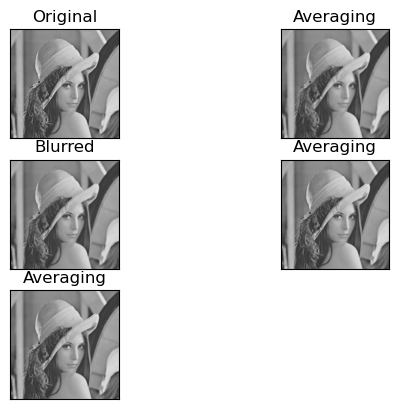

In [ ]:
kernel = np.ones((5,5),np.float32)/25
dst = cv2.filter2D(img1,-1,kernel)
blur_1 = cv2.blur(img1,(5,5))
blur_2 = cv2.GaussianBlur(img1,(5,5),0)
median = cv2.medianBlur(img1,5)

plt.subplot(321),plt.imshow(img1),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(322),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.subplot(323),plt.imshow(blur_1),plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.subplot(324),plt.imshow(blur_2),plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.subplot(325),plt.imshow(blur_2),plt.title('Median')
plt.xticks([]), plt.yticks([])
plt.show()